# Autonomous Agent란?

**Autonomous Agent**는 **높은 자율성**을 가지고 동적으로 의사결정하며 작업하는 가장 고급 형태의 Multi-Agent 패턴입니다.

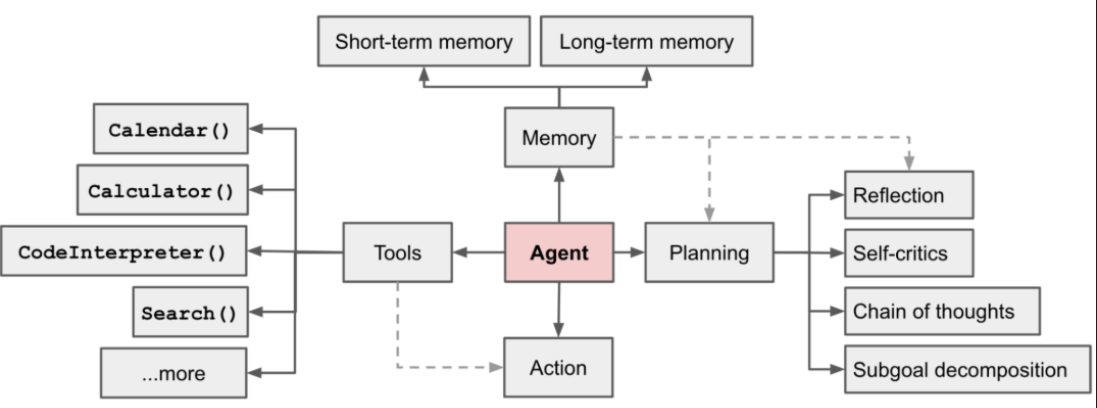

## 핵심 특징

1. **자율적 의사결정** (Autonomous Decision-Making)
   - 미리 정해진 경로가 아닌, 상황에 따라 스스로 판단
   - 목표 달성을 위한 최적의 경로 선택
   
2. **동적 워크플로우** (Dynamic Workflow)
   - 실행 중에 워크플로우가 변경됨
   - 조건에 따라 에이전트를 건너뛰거나 반복
   
3. **루프와 재귀** (Loop & Recursion)
   - 목표 달성까지 작업 반복
   - 결과가 만족스럽지 않으면 다시 시도
   
4. **Human-in-the-Loop (HITL)**
   - 중요한 결정에 사용자 개입
   - 사람의 판단과 AI의 자동화 결합

5. **메타인지** (Meta-cognition)
   - 자신의 작업을 평가하고 개선
   - "이 결과가 충분한가?" 스스로 판단


## 작동 방식

```
시작
  ↓
계획 수립 (Planning)
  ↓
작업 실행
  ↓
결과 검증 (Self-evaluation)
  ↓
만족스러운가?
  ├─ Yes → 완료
  └─ No → 추가 작업 필요
         ↓
      다시 계획 (Loop) 
         ↓
      반복...
```


## vs. 다른 패턴

| 패턴 | 워크플로우 | 자율성 | 반복 | 복잡도 |
|------|-----------|-------|------|--------|
| **Hierarchical** | 고정 | 낮음 | ❌ | ⭐ |
| **Sequential** | 고정 | 낮음 | ❌ | ⭐⭐ |
| **Collaborative** | 고정 | 중간 | ❌ | ⭐⭐⭐ |
| **Supervisor** | 반고정 | 중간 | △ | ⭐⭐⭐⭐ |
| **Autonomous** | **동적** | **높음** | **✅** | **⭐⭐⭐⭐⭐** |

# Multi Agents - 자율 연구 에이전트 (with Memory & interrupt)
LangGraph를 활용하여 동적 워크플로우, 루프/재귀, Human-in-the-loop 패턴을 구현하는 자율 연구 시스템을 만듭니다.

**주요 기능:**
- ✅ **MemorySaver**: 상태 지속성, 여러 세션 동시 관리
- ✅ **interrupt**: input() 없이 Human-in-the-Loop 구현
- ✅ **셀 단위 실행**: Jupyter 노트북에서 각 단계를 독립적으로 실행 가능
- ✅ **테스트 가능**: 자동화된 테스트 작성 가능

## 이 예제가 Autonomous Agent인 이유

**자율 연구 에이전트**는 Autonomous Agent의 모든 특징을 보여줍니다:

### 1. 자율적 의사결정
- **계획 에이전트**: 연구 주제를 스스로 분석하고 계획 수립
- **조정 에이전트**: "정보가 충분한가?" 스스로 판단
  - 부족하면 → 다시 검색
  - 충분하면 → 보고서 작성

### 2. 동적 워크플로우
```
계획 → 검색 → 분석 → 검증
                    ↓
              충분한가?
            No ↓      ↓ Yes
            검색으로   보고서
            다시 ←
```
- 미리 정해진 것이 아님
- 검증 결과에 따라 경로 변경

### 3. 루프와 재귀
- 정보가 부족하면 검색-분석-검증을 **반복**
- 최대 N회까지 반복 (무한 루프 방지)
- 각 반복마다 개선됨

### 4. Human-in-the-Loop (interrupt 방식)
- 중요한 결정 시점에 실행을 자동 중단
- **interrupt_before=["human_review"]** 설정으로 구현
- 사용자가 상태를 검토하고 결정:
  ```
  옵션 A: app.update_state(config, {'human_approval': True})
          → 추가 검색 수행
  옵션 B: app.update_state(config, {'human_approval': False})
          → 현재 결과로 보고서 작성
  ```
- **장점**: input() 불필요, 셀 단위 실행 가능, 테스트 자동화 가능

### 5. 메타인지
- **검증 에이전트**가 자체 평가:
  - "수집한 정보의 신뢰성은?"
  - "연구 목표를 달성했는가?"
  - "추가 조사가 필요한가?"


## 자율 연구 에이전트의 실제 흐름

**연구 주제**: "LangChain의 최신 트렌드"

```
1단계: 계획 에이전트
   출력: "LangChain 공식 문서, 최근 블로그, GitHub 이슈 조사 필요"

2단계: 검색 에이전트
   행동: 웹 검색 실행
   결과: 10개 문서 수집

3단계: 분석 에이전트
   행동: 문서 내용 분석
   결과: 주요 트렌드 5가지 추출

4단계: 검증 에이전트
   평가: "정보가 부족함. 구체적 예제 필요"
   결론: 추가 조사 필요

5단계: 조정 에이전트
   결정: 다시 검색으로 돌아가기
   지시: "LangChain 예제 코드 검색"

[2-4단계 반복]

6단계: 검증 에이전트 (2차)
   평가: "충분한 정보 확보"
   결론: 보고서 작성 가능

7단계: 보고서 에이전트
   행동: 최종 연구 보고서 작성
```


## 장점과 도전과제

**장점**:
- **유연성**: 상황에 맞게 적응
- **효율성**: 불필요한 작업 생략
- **품질**: 자체 검증으로 개선
- **협업**: 사람과 AI의 결합

**도전과제**:
- **복잡성**: 구현과 디버깅 어려움
- **실행 시간**: 반복으로 인한 지연
- **비용**: LLM 호출 횟수 증가
- **제어**: 예측 불가능한 동작

## 적합한 사용 사례

- **연구 및 조사**: 심층 리서치
- **복잡한 문제 해결**: 다단계 추론
- **창의적 작업**: 글쓰기, 디자인 기획
- **품질이 중요한 작업**: 여러 번 검토
- **탐색적 작업**: 정답이 불명확한 경우

## 구현 시 고려사항

1. **최대 반복 횟수 설정**: 무한 루프 방지
2. **조기 종료 조건**: 충분한 결과 시 중단
3. **비용 모니터링**: LLM 호출 추적
4. **사용자 개입 시점**: 언제 HITL 활용할지
5. **상태 저장**: 각 단계 결과 기록


## 구성
1. **계획 에이전트**: 연구 주제 분석 및 계획 수립
2. **검색 에이전트**: 정보 수집 및 자료 검색
3. **분석 에이전트**: 수집된 데이터 분석
4. **검증 에이전트**: 정보의 신뢰성과 완성도 검증
5. **조정 에이전트**: 추가 조사 필요 여부 판단 및 워크플로우 제어
6. **보고서 에이전트**: 최종 연구 보고서 작성

## 학습 목표
- 동적 워크플로우 (Dynamic Workflow): 실행 중 경로 변경
- 루프와 재귀 (Loop & Recursion): 조건에 따라 반복 실행
- Human-in-the-loop (HITL): interrupt를 사용한 사용자 개입
- MemorySaver: 상태 지속성 및 여러 세션 관리
- 셀 단위 실행: input() 없이 Jupyter 노트북에서 테스트 가능


# 예제 

## 1단계: LLM


### API 키 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [Tavily API Key](https://tavily.com/) - 실제 웹 검색 기능 사용

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

### LLM 초기화

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

## 2단계: 상태 정의 (State Management)

고급 워크플로우를 위한 복잡한 상태 구조를 정의합니다. 루프 제어, 이력 관리, 검증 상태 등을 포함합니다.


In [3]:
from typing import TypedDict, List, Literal, Annotated
from operator import add

class ResearchState(TypedDict):
    """
    자율 연구 시스템의 상태를 정의하는 클래스
    """
    topic: str                                      # 연구 주제
    research_plan: str                              # 연구 계획
    search_results: Annotated[List[str], add]       # 검색 결과 리스트 (누적)
    analysis_results: Annotated[List[str], add]     # 분석 결과 리스트 (누적)
    verification_status: str                        # 검증 상태 (passed/failed)
    verification_feedback: str                      # 검증 피드백
    needs_more_research: bool                       # 추가 연구 필요 여부
    iteration_count: int                            # 반복 횟수 (무한 루프 방지)
    max_iterations: int                             # 최대 반복 횟수 (주제 복잡도에 따라 동적 설정)
    human_approval: bool                            # 사용자 승인 여부
    final_report: str                               # 최종 보고서

    

## 3단계: 에이전트 노드 정의


### 복잡도 에이전트


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

def complexity_level_of_topic_agent(state: ResearchState) -> dict:
    """
    주제의 복잡도를 평가하여 최대 반복 횟수를 동적으로 설정하는 에이전트
    """
    topic = state["topic"]
    
    complexity_messages = [
        SystemMessage(content="""
            당신은 연구 주제 복잡도 평가 전문가입니다.
            주어진 주제의 복잡도를 평가하세요:

            - SIMPLE: 단순하고 명확한 주제 (예: 특정 기술 소개, 단일 개념 설명)
            - MODERATE: 중간 복잡도 주제 (예: 기술 비교, 트렌드 분석)
            - COMPLEX: 복잡한 주제 (예: 다면적 분석, 미래 예측, 철학적 논의)

            반드시 "COMPLEXITY: SIMPLE", "COMPLEXITY: MODERATE", "COMPLEXITY: COMPLEX" 중 하나로 시작하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n이 주제의 복잡도를 평가하세요.")
    ]
    
    complexity_response = llm.invoke(complexity_messages)
    complexity_text = complexity_response.content
    
    # 복잡도에 따른 최대 반복 횟수 설정
    if "COMPLEXITY: SIMPLE" in complexity_text:
        max_iterations = 2
        complexity_level = "단순"
    elif "COMPLEXITY: COMPLEX" in complexity_text:
        max_iterations = 4
        complexity_level = "복잡"
    else:
        max_iterations = 3
        complexity_level = "중간"
    
    print(f"[주제의 복잡도 에이전트] 주제 복잡도: {complexity_level} (최대 {max_iterations}회 반복)")
        
    return {
        "max_iterations": max_iterations
    }

### 계획 에이전트

In [5]:
def __planning_of_topic(state: ResearchState):
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립
    """
    topic = state["topic"]

    # 재연구인 경우 피드백 반영
    feedback = state.get("verification_feedback", "")
    feedback_context = f"\n\n이전 피드백: {feedback}" if feedback else ""
    
    messages = [
        SystemMessage(content="""
            당신은 연구 계획 전문가입니다.
            주어진 주제에 대해 체계적인 연구 계획을 수립하세요:
            1. 핵심 조사 질문 정의
            2. 필요한 정보 유형 파악
            3. 검색 키워드 제안
            4. 분석 방향 제시

            간결하고 실행 가능한 계획을 작성하세요."""),
        HumanMessage(content=f"주제: {topic}{feedback_context}\n\n연구 계획을 수립하세요.")
    ]
    
    response = llm.invoke(messages)
    
    return response.content

In [6]:
def planning_agent(state: ResearchState) -> dict:
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립하는 에이전트
    """
    iteration_count = state.get('iteration_count', 0)
    max_iterations = state['max_iterations']
    
    plan = __planning_of_topic(state)
    
    print(f"[계획 에이전트] 연구 계획 수립 완료 (반복 {iteration_count + 1}회 / 최대 {max_iterations}회)")
    
    return {
        "research_plan": plan,
        "iteration_count": iteration_count + 1,
        "max_iterations": max_iterations
    }


### 검색 에이전트 (TavilySearch 사용)

실제 웹 검색을 수행하는 에이전트입니다. 

**TavilySearch 사용:**
- Tavily API 키가 있으면 실제 웹 검색 수행
- Tavily API 키가 없으면 시뮬레이션 모드로 작동
- API 키 발급: [Tavily](https://tavily.com/)

**참고:** Tavily API 키를 설정하려면 위의 API 키 설정 셀에서 주석을 제거하고 키를 입력하세요.


In [7]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=3,
    topic="general",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=True,     # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="advanced",          # "basic" 또는 "advanced"
    include_domains=[
        "https://www.naver.com", # 뉴스
        "https://www.weatheri.co.kr/", # 날씨 
        "https://kr.investing.com/equities/south-korea" # 주식
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

In [8]:
def search_agent(state: ResearchState) -> dict:
    """
    연구 계획에 따라 정보를 검색하고 수집하는 에이전트
    TavilySearchResults를 사용하여 실제 웹 검색 수행
    """
    topic = state["topic"]
    iteration = state['iteration_count']
    
    # Tavily 검색이 가능한 경우 실제 웹 검색 수행
    # 검색 쿼리 생성 (주제 + 계획의 핵심 키워드)
    search_query = f"{topic}"
    
    print(f"[검색 에이전트] 웹 검색 실행: {search_query}")
    
    # 실제 웹 검색 수행
    search_results_raw = tavily_search.invoke({"query": search_query})
    
    # 검색 결과를 포맷팅
    formatted_results = []
    for i, result in enumerate(search_results_raw['results'], 1):
        url = result.get('url', 'N/A')
        content = result.get('content', 'N/A')
        formatted_results.append(f"출처 {i}: {url}\n내용: {content}")
    
    search_result_text = "\n\n".join(formatted_results)
    
    # LLM을 사용하여 검색 결과 요약 및 분석
    summary_messages = [
        SystemMessage(content="""
        당신은 정보 분석 전문가입니다.
        웹 검색 결과를 분석하여 연구 주제와 관련된 핵심 정보를 요약하세요.
        - 각 출처의 주요 내용 정리
        - 관련성 높은 정보 강조
        - 상충되는 정보가 있다면 명시"""),
        HumanMessage(content=f"""
        주제: {topic}
        
        검색 결과:
        {search_result_text}
        
        이 결과를 요약하고 분석하세요.""")
    ]
    
    summary_response = llm.invoke(summary_messages)
    
    search_result = f"""
    [실제 웹 검색 결과 - 반복 {iteration}]
    
    {summary_response.content}
    
    --- 원본 검색 결과 ---
    {search_result_text[:500]}..."""
    
    print(f"[검색 에이전트] 실제 웹 검색 완료 ({len(search_results_raw)}개 결과)")
    
    return {
        "search_results": [search_result]
    }


### 분석 에이전트


In [9]:
def analysis_agent(state: ResearchState) -> dict:
    """
    수집된 정보를 분석하고 인사이트를 도출하는 에이전트
    """
    topic = state["topic"]
    search_results = state["search_results"]
    
    # 최신 검색 결과만 분석 (또는 전체 분석)
    recent_results = "\n\n".join(search_results[-3:])  # 최근 3개
    
    messages = [
        SystemMessage(content="""
            당신은 데이터 분석 전문가입니다.
            수집된 정보를 분석하여:
            1. 핵심 패턴과 트렌드 파악
            2. 주요 발견사항 정리
            3. 상충되는 정보 식별
            4. 추가 조사가 필요한 부분 지적

            분석적이고 비판적인 관점을 유지하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n검색 결과:\n{recent_results}\n\n이 정보를 분석하세요.")
    ]
    
    response = llm.invoke(messages)
    analysis = f"[분석 결과 - 반복 {state['iteration_count']}]\n{response.content}"
    
    print(f"[분석 에이전트] 데이터 분석 완료")
    
    return {
        "analysis_results": [analysis]
    }


### 검증 에이전트


In [10]:
def verification_agent(state: ResearchState) -> dict:
    """
    정보의 신뢰성과 완성도를 검증하는 에이전트
    """
    topic = state["topic"]
    analysis_results = state["analysis_results"]
    
    # 최신 분석 결과 검토
    recent_analysis = "\n\n".join(analysis_results[-2:])
    
    messages = [
        SystemMessage(content="""
            당신은 연구 품질 검증 전문가입니다.
            분석 결과를 검토하고 다음을 판단하세요:
            1. 정보의 충분성 (충분한가?)
            2. 정보의 신뢰성 (출처가 믿을만한가?)
            3. 논리의 일관성 (모순이 없는가?)
            4. 추가 조사 필요 여부

            반드시 다음 형식으로 시작하세요:
            STATUS: PASSED 또는 STATUS: NEEDS_MORE_RESEARCH

            그 다음 상세한 피드백을 제공하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n분석 결과:\n{recent_analysis}\n\n검증 결과를 제공하세요.")
    ]
    
    response = llm.invoke(messages)
    verification_result = response.content
    
    # 검증 상태 파싱
    if "STATUS: PASSED" in verification_result:
        status = "passed"
        needs_more = False
        print(f"[검증 에이전트] 검증 통과")
    else:
        status = "needs_more_research"
        needs_more = True
        print(f"[검증 에이전트] 추가 조사 필요")
    
    return {
        "verification_status": status,
        "verification_feedback": verification_result,
        "needs_more_research": needs_more
    }


### 조정 에이전트


In [11]:
def coordination_agent(state: ResearchState) -> dict:
    """
    워크플로우를 제어하고 다음 단계를 결정하는 에이전트
    동적으로 설정된 최대 반복 횟수를 사용
    """
    iteration = state["iteration_count"]
    needs_more = state["needs_more_research"]
    max_iterations = state.get("max_iterations", 3)  # 동적 최대 반복 횟수
    
    if needs_more and iteration < max_iterations:
        print(f"[조정 에이전트] 추가 조사 필요 - 검색으로 돌아갑니다 (반복 {iteration}/{max_iterations})")
        return {}
    elif iteration >= max_iterations:
        print(f"[조정 에이전트] 최대 반복 횟수 도달 ({max_iterations}회) - 현재 결과로 진행합니다")
        return {
            "needs_more_research": False,
            "verification_status": "max_iterations_reached"
        }
    else:
        print(f"[조정 에이전트] 연구 완료 - 보고서 작성 단계로 진행")
        return {}

#### Human-in-the-loop 노드

In [12]:
# Human-in-the-loop 노드
def human_review_node(state: ResearchState) -> dict:
    """
    사용자의 승인을 받는 노드 (Human-in-the-loop)
    interrupt를 사용하여 실행을 일시 중지하고 사용자 입력을 대기합니다.
    """
    print("\n" + "="*80)
    print("[Human-in-the-loop] 사용자 검토 요청")
    print("="*80)
    print(f"현재 반복: {state['iteration_count']}/{state.get('max_iterations', 3)}")
    print(f"검증 상태: {state['verification_status']}")
    print(f"\n검증 피드백:\n{state['verification_feedback'][:300]}...")
    print("="*80)
    print("이 시점에서 실행이 중단됩니다.")
    print("다음 셀에서 승인 여부를 결정하고 실행을 재개할 수 있습니다.")
    print("="*80)
    
    # 상태를 그대로 반환 (human_approval은 나중에 업데이트됨)
    return {}


### 보고서 에이전트


In [13]:
def report_agent(state: ResearchState) -> dict:
    """
    모든 연구 결과를 종합하여 최종 보고서를 작성하는 에이전트
    """
    topic = state["topic"]
    plan = state["research_plan"]
    all_search = "\n\n".join(state["search_results"])
    all_analysis = "\n\n".join(state["analysis_results"])
    iterations = state["iteration_count"]
    
    messages = [
        SystemMessage(content="""
            당신은 연구 보고서 작성 전문가입니다.
            수집되고 분석된 모든 정보를 종합하여 체계적인 최종 보고서를 작성하세요:

            1. 요약 (Executive Summary)
            2. 연구 배경 및 목적
            3. 주요 발견사항
            4. 상세 분석
            5. 결론 및 제언
            6. 한계점 및 향후 연구 방향

            전문적이고 명확한 보고서를 작성하세요."""),
        HumanMessage(content=f"""
            주제: {topic}

            연구 계획:
            {plan}

            검색 결과:
            {all_search}

            분석 결과:
            {all_analysis}

            (총 {iterations}회 반복 조사 수행)

            위 내용을 바탕으로 최종 보고서를 작성하세요.""")
    ]
    
    response = llm.invoke(messages)
    report = response.content
    
    print(f"[보고서 에이전트] 최종 보고서 작성 완료")
    
    return {
        "final_report": report
    }


## 4단계: 동적 라우팅 함수

조건에 따라 다음 노드를 동적으로 결정하는 라우팅 함수들을 정의합니다.


In [14]:
def route_after_verification(state: ResearchState) -> Literal["human_review", "coordination"]:
    """
    검증 후 Human-in-the-loop 또는 조정으로 라우팅
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하거나 최대 반복 도달 시 사람 검토
    needs_review = (
        state["needs_more_research"] or 
        state["iteration_count"] >= max_iterations
    )
    
    if needs_review:
        return "human_review"
    else:
        return "coordination"

In [15]:
def route_after_human_review(state: ResearchState) -> Literal["coordination", "report"]:
    """
    Human review 후 라우팅
    """
    if not state["human_approval"]:
        # 사용자가 거부한 경우 바로 보고서로 (중단)
        return "report"
    else:
        return "coordination"

In [16]:
def route_after_coordination(state: ResearchState) -> Literal["planning", "report"]:
    """
    조정 에이전트 후 루프 또는 종료 결정
    동적으로 설정된 최대 반복 횟수 사용
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하고 최대 반복 미만이면 루프
    if state["needs_more_research"] and state["iteration_count"] < max_iterations:
        return "planning"  # 루프: 계획으로 돌아감
    else:
        return "report"  # 종료: 보고서 작성


## 5단계: 그래프 구성 (동적 워크플로우 + 루프)

복잡한 워크플로우를 구성합니다. 조건에 따라 경로가 변경되고, 필요시 루프를 돕니다.

### 그래프 구조
```
시작
  |
  v
복잡도
  |
  v
계획 <----------+
  |             |
  v             |
검색            | (루프)
  |             |
  v             |
분석            |
  |             |
  v             |
검증            |
  |             |
  v             |
Human Review?   |
  |             |
  v             |
조정 -----------+
  |
  v
보고서
  |
  v
종료
```


In [17]:
from langgraph.graph import StateGraph, END

# StateGraph 생성
workflow = StateGraph(ResearchState)

# 노드 추가
workflow.add_node("complexity_level", complexity_level_of_topic_agent)
workflow.add_node("planning", planning_agent)
workflow.add_node("search", search_agent)
workflow.add_node("analysis", analysis_agent)
workflow.add_node("verification", verification_agent)
workflow.add_node("human_review", human_review_node)
workflow.add_node("coordination", coordination_agent)
workflow.add_node("report", report_agent)

# 시작점 설정
workflow.set_entry_point("complexity_level")

# 순차적 연결 (계획 -> 검색 -> 분석 -> 검증)
workflow.add_edge("complexity_level", "planning")
workflow.add_edge("planning", "search")
workflow.add_edge("search", "analysis")
workflow.add_edge("analysis", "verification")

# 검증 후 조건부 라우팅 (Human review 필요 여부)
workflow.add_conditional_edges(
    "verification",
    route_after_verification,
    {
        "human_review": "human_review",
        "coordination": "coordination"
    }
)

# Human review 후 라우팅
workflow.add_conditional_edges(
    "human_review",
    route_after_human_review,
    {
        "coordination": "coordination",
        "report": "report"
    }
)

# 조정 후 조건부 라우팅 (루프 또는 종료)
workflow.add_conditional_edges(
    "coordination",
    route_after_coordination,
    {
        "planning": "planning",  # 루프: 다시 계획으로
        "report": "report"       # 종료: 보고서로
    }
)

# 보고서에서 종료
workflow.add_edge("report", END)

# MemorySaver를 사용하여 그래프 컴파일
# MemorySaver는 대화 기록을 메모리에 저장하여 세션 간 상태를 유지합니다
# interrupt_before를 사용하여 human_review 노드 전에 실행을 중단합니다
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
app = workflow.compile(
    checkpointer=memory,
    interrupt_before=["human_review"]  # human_review 노드 전에 실행 중단
)



## 6단계: 그래프 시각화 (선택사항)


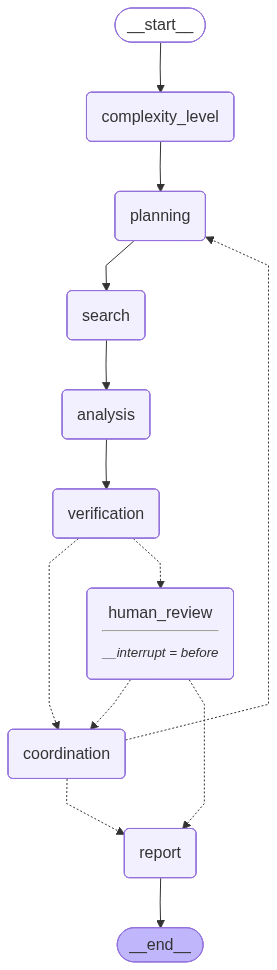

In [18]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 7단계: 테스트 예제

자율 연구 시스템을 실행해봅니다.


### 연구 주제 설정


In [19]:
research_topic = "LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례"

print(f"연구 주제: {research_topic}")


연구 주제: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례


### 자율 연구 실행 (MemorySaver 사용)

**MemorySaver 기능:**
- 각 연구 세션의 상태를 메모리에 저장
- thread_id로 여러 연구를 독립적으로 관리
- 동일한 thread_id로 실행하면 이전 상태를 이어서 진행 가능

**Human-in-the-loop:**
- 검증 단계에서 사용자 승인 요청
- 사용자가 진행 여부를 결정


In [21]:
import uuid

print("=" * 80)
print("자율 연구 시스템 시작 (MemorySaver + interrupt 적용)")
print("=" * 80)

# 초기 상태
initial_state = {
    "topic": research_topic
}

# thread_id를 사용하여 세션 관리
# 동일한 thread_id를 사용하면 이전 상태를 이어서 진행할 수 있습니다
thread_id = str(uuid.uuid4())

# config 설정 (thread_id 포함)
config = {
    "configurable": {
        "thread_id": thread_id
    }
}

print(f"Thread ID: {thread_id}")
print("이 Thread ID로 상태가 저장됩니다.\n")

# 그래프 실행 (config와 함께)
# interrupt_before=["human_review"] 설정으로 인해 human_review 노드 전에 중단됩니다
print("그래프 실행 중...")
result = app.invoke(initial_state, config=config)

print("\n" + "=" * 80)
print("Human-in-the-loop 지점에서 실행이 중단되었습니다!")
print("다음 셀에서 승인 여부를 결정하고 실행을 재개하세요.")
print("=" * 80)


자율 연구 시스템 시작 (MemorySaver + interrupt 적용)
Thread ID: cd667368-52c1-4adf-be6f-57f83d005a4c
이 Thread ID로 상태가 저장됩니다.

그래프 실행 중...
[주제의 복잡도 에이전트] 주제 복잡도: 중간 (최대 3회 반복)
[계획 에이전트] 연구 계획 수립 완료 (반복 1회 / 최대 3회)
[검색 에이전트] 웹 검색 실행: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례
[검색 에이전트] 실제 웹 검색 완료 (7개 결과)
[분석 에이전트] 데이터 분석 완료
[검증 에이전트] 추가 조사 필요

Human-in-the-loop 지점에서 실행이 중단되었습니다!
다음 셀에서 승인 여부를 결정하고 실행을 재개하세요.


### Human 검토 (1단계: 현재 상태 상세 확인)

interrupt로 중단된 시점에서 현재까지의 연구 결과를 상세히 검토합니다.


In [22]:
# Human 검토: 현재까지의 연구 결과를 상세히 확인

print("=" * 80)
print("🔍 Human 검토 - 현재 상태 상세 분석")
print("=" * 80)

# 현재 상태 가져오기
current_state = app.get_state(config)
print("\n" + "=" * 80)
print(f"기본 정보:")
print(f"  - Thread ID: {thread_id}")
print(f"  - 중단 지점: {current_state.next}")
print(f"  - 현재 반복: {current_state.values.get('iteration_count', 0)}/{current_state.values.get('max_iterations', 0)}")
print(f"  - 검증 상태: {current_state.values.get('verification_status', 'N/A')}")

print("\n" + "=" * 80)
print(f"검증 피드백:")
print("-" * 80)
verification_feedback = current_state.values.get('verification_feedback', '없음')
print(verification_feedback)
print("-" * 80)

print("\n" + "=" * 80)
print(f"수집된 데이터:")
search_results = current_state.values.get('search_results', [])
analysis_results = current_state.values.get('analysis_results', [])
print(f"  - 검색 수행: {len(search_results)}회")
print(f"  - 분석 수행: {len(analysis_results)}회")

if search_results:
    print(f"최근 검색 결과 미리보기:")
    latest_search = search_results[-1]
    print(latest_search[:500] + "..." if len(latest_search) > 500 else latest_search)

if analysis_results:
    print(f"최근 분석 결과 미리보기:")
    latest_analysis = analysis_results[-1]
    print(latest_analysis[:500] + "..." if len(latest_analysis) > 500 else latest_analysis)


print("\n" + "=" * 80)
print("검토 포인트:")
print("  1. 검증 피드백을 확인하세요")
print("  2. 현재 수집된 정보가 충분한지 판단하세요")
print("  3. 추가 조사가 필요한지 결정하세요")
print("=" * 80)


🔍 Human 검토 - 현재 상태 상세 분석

기본 정보:
  - Thread ID: cd667368-52c1-4adf-be6f-57f83d005a4c
  - 중단 지점: ('human_review',)
  - 현재 반복: 1/3
  - 검증 상태: needs_more_research

검증 피드백:
--------------------------------------------------------------------------------
STATUS: NEEDS_MORE_RESEARCH

상세 피드백

1) 정보의 충분성
- 장점: 분석은 LangGraph의 그래프 기반 관리, LCEL과 그래프 흐름의 결합으로 노드 단위 로직 재사용성과 흐름 제어의 유연성을 확보한다는 점, 생산 운영 도구의 중요성, 생태계 확장 및 표준화 시도라는 핵심 패턴을 체계적으로 정리하고 있습니다.
- 한계: 실제 사례에 대한 구체적 수치(성능 벤치마크, 개발 속도, 운영 비용, 장애 복구 시간 등)나 독립적 벤치마크가 제시되어 있지 않습니다. 출처를 명시한 구체적인 연구나 데이터가 부족하고, “출처 1/2/3”에 대한 상세 정보가 제공되지 않아 근거의 신뢰성을 평가하기 어렵습니다.
- 결론: 정보의 범주는 주제에 대한 고찰을 위한 충분한 출발점이지만, 의사결정을 위한 충분성은 부족합니다. 구체적 수치와 독립 검증 자료가 필요합니다.

2) 정보의 신뢰성
- 장점: 분석은 생태계 확장과 표준화 논의의 이슈를 균형 있게 제시하고 있으며, “개방 표준(MCP)”의 가능성과 위험을 함께 다루고 있습니다. 이를 통해 편향을 어느 정도 상쇄하려는 의도가 보입니다.
- 한계: 출처의 상세 목록이 없고, 특정 주장에 대해 독립적 검증 여부가 불투명합니다. 제조사/벤더 주도 문맥일 가능성이 있으며, 표준화의 효과를 뒷받침하는 독립적 데이터가 부족합니다.
- 결론: 신뢰성은 정보 출처의 불명확성과 독립 검증의 부재로 인해 제한적입니다. 구체적 출처를 확인하고, 독립적/비용-효과 관점의 검증 자료

### Human 승인 (2단계: 결정 및 실행)

검토 결과를 바탕으로 다음 중 하나를 선택하세요:
- **옵션 1 (다음 셀)**: 계속 진행 (human_approval=True) - 추가 조사 수행
- **옵션 2 (그 다음 셀)**: 중단 (human_approval=False) - 현재 결과로 보고서 작성


In [23]:
# 옵션 1: 계속 진행 (승인) - 추가 조사 수행
# 검토 결과 정보가 부족하다고 판단되면 이 셀을 실행하세요

print("=" * 80)
print("옵션 1 선택: 계속 진행 (승인)")
print("=" * 80)

# 상태 업데이트: human_approval=True 설정
app.update_state(config, {"human_approval": True})

print("✓ 승인됨 - 추가 조사를 위해 실행 재개 중...")

# 실행 재개 (None을 전달하여 이전 상태에서 계속)
result = app.invoke(None, config=config)

print("\n" + "=" * 80)
print("추가 조사 완료!")
print("다음 Human-in-the-loop 지점에서 다시 중단되거나, 최종 보고서가 작성됩니다.")
print("=" * 80)


옵션 1 선택: 계속 진행 (승인)
✓ 승인됨 - 추가 조사를 위해 실행 재개 중...

[Human-in-the-loop] 사용자 검토 요청
현재 반복: 1/3
검증 상태: needs_more_research

검증 피드백:
STATUS: NEEDS_MORE_RESEARCH

상세 피드백

1) 정보의 충분성
- 장점: 분석은 LangGraph의 그래프 기반 관리, LCEL과 그래프 흐름의 결합으로 노드 단위 로직 재사용성과 흐름 제어의 유연성을 확보한다는 점, 생산 운영 도구의 중요성, 생태계 확장 및 표준화 시도라는 핵심 패턴을 체계적으로 정리하고 있습니다.
- 한계: 실제 사례에 대한 구체적 수치(성능 벤치마크, 개발 속도, 운영 비용, 장애 복구 시간 등)나 독립적 벤치마크가 제시되어 있지 않습니다. 출처를 명시한 구체적인 연구나 데이터가 부족하...
이 시점에서 실행이 중단됩니다.
다음 셀에서 승인 여부를 결정하고 실행을 재개할 수 있습니다.
[조정 에이전트] 추가 조사 필요 - 검색으로 돌아갑니다 (반복 1/3)
[계획 에이전트] 연구 계획 수립 완료 (반복 2회 / 최대 3회)
[검색 에이전트] 웹 검색 실행: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례
[검색 에이전트] 실제 웹 검색 완료 (7개 결과)
[분석 에이전트] 데이터 분석 완료
[검증 에이전트] 추가 조사 필요

추가 조사 완료!
다음 Human-in-the-loop 지점에서 다시 중단되거나, 최종 보고서가 작성됩니다.


### 옵션 2: 중단 후 보고서 작성 (거부)

현재 결과로 만족하고 추가 조사 없이 바로 보고서를 작성하고 싶은 경우 사용합니다.
**주의**: 옵션 1 대신 이 셀을 실행하세요.


In [24]:
# 옵션 2: 중단 후 보고서 작성 (거부) - 현재 결과로 보고서 작성
# 검토 결과 현재 정보로 충분하다고 판단되면 이 셀을 실행하세요
# 주의: 옵션 1 셀을 실행하지 않았을 때만 이 셀을 실행하세요

print("=" * 80)
print("옵션 2 선택: 중단 후 보고서 작성 (거부)")
print("=" * 80)

# 상태 업데이트: human_approval=False 설정
app.update_state(config, {"human_approval": False})

print("✗ 거부됨 - 추가 조사 없이 현재 결과로 보고서 작성 중...")

# 실행 재개 (None을 전달하여 이전 상태에서 계속)
result = app.invoke(None, config=config)

print("\n" + "=" * 80)
print("연구 완료! 최종 보고서가 작성되었습니다.")
print("=" * 80)


옵션 2 선택: 중단 후 보고서 작성 (거부)
✗ 거부됨 - 추가 조사 없이 현재 결과로 보고서 작성 중...

[Human-in-the-loop] 사용자 검토 요청
현재 반복: 2/3
검증 상태: needs_more_research

검증 피드백:
STATUS: NEEDS_MORE_RESEARCH

상세 피드백

1) 정보의 충분성
- 강점과 한계를 잘 구분하고, 상충되는 정보도 지적하는 점은 긍정적입니다. 다만 구체적 근거가 불충분합니다.
- 실제 벤치마크 수치, 기업 사례의 구체적 데이터, 독립 검증 결과 등이 제시되지 않아 일반화에 주의가 필요합니다.
- 출처를 “출처 1/2/3”로만 언급하고 구체적 출처 명시나 인용 정보가 없어 재현성과 신뢰성 확보가 어렵습니다. 방법론(검색 범위, 선정 기준, 합의된 품질 평가 등)이 명시되어야 합니다.
- 현황 요약은 포괄적이나, ...
이 시점에서 실행이 중단됩니다.
다음 셀에서 승인 여부를 결정하고 실행을 재개할 수 있습니다.
[보고서 에이전트] 최종 보고서 작성 완료

연구 완료! 최종 보고서가 작성되었습니다.


### 최종 보고서 확인


In [25]:
print("\n" + "=" * 80)
print("최종 연구 보고서")
print("=" * 80)
print(f"\n총 반복 횟수: {result['iteration_count']}")
print(f"검증 상태: {result['verification_status']}")
print("\n" + "-" * 80)
print(result["final_report"])
print("-" * 80)



최종 연구 보고서

총 반복 횟수: 2
검증 상태: needs_more_research

--------------------------------------------------------------------------------
LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례에 대한 체계적 보고서

1. Executive Summary
- 목적과 범위: LangGraph를 중심으로 LCEL과의 결합 가능성, 그리고 생태계 확장성(Open 표준 MCP 등)까지 포괄적으로 평가해, 다중에이전트(MAS) 시스템에서의 모듈성, 재사용성, 흐름 제어의 유연성에 대한 실제적 이점과 도전과제를 도출하고자 하였습니다. 본 보고서는 두 차례의 자료 분석(반복 연구)을 통합하여, 이론적 가능성과 실무적 실행 가능성을 균형 있게 제시합니다.
- 핵심 요지
  - 강점: 그래프 기반의 흐름 제어와 상태 관리를 통해 MAS의 모듈화와 재사용성을 높이고, LCEL과의 하이브리드 설계로 노드 단위 로직의 재사용성과 흐름 제어의 유연성을 확보할 수 있습니다. LangGraph Platform과 LangSmith를 통한 운영/관측 기능은 프로덕션 환경의 신뢰성 확보에 기여합니다.
  - 생태계/표준화의 기회: MCP와 같은 개방 표준 도입은 에이전트 간 협업과 도구 간 상호운용성을 촉진할 가능성이 있습니다. LangChain/LangGraph 생태계의 확장은 MAS 구현의 선택지를 넓히는 동시에 표준화의 필요성도 함께 부각합니다.
  - 위험 및 제약: 도입 초기의 설계 복잡성, 학습 곡선, 프레임워크 간 통합의 난이도, 그리고 표준화 수준의 차이로 인한 운영 비용 증가 가능성을 고려해야 합니다. 또한 현재 제시되는 수치나 사례는 주로 홍보성 자료이므로 독립적 검증이 필요합니다.
- 실무적 시사점
  - 복잡한 다중 에이전트 흐름과 고급 제어가 핵심인 경우 LangGraph의 도입이 합리적입니다. 반대로 간단한 체인 구동이나 단순 RAG 흐름은 LC

### 연구 과정 추적 및 MemorySaver 상태 확인


In [26]:
# 저장된 상태 조회
print("\n" + "=" * 80)
print("MemorySaver 상태 확인")
print("=" * 80)

# 현재 thread의 상태 가져오기
state_snapshot = app.get_state(config)

print(f"\nThread ID: {thread_id}")
print(f"현재 상태:")
print(f"  - 반복 횟수: {state_snapshot.values.get('iteration_count', 0)}")
print(f"  - 최대 반복 횟수: {state_snapshot.values.get('max_iterations', 0)}")
print(f"  - 검증 상태: {state_snapshot.values.get('verification_status', 'N/A')}")
print(f"  - Human 승인: {state_snapshot.values.get('human_approval', 'N/A')}")
print(f"  - 검색 결과 수: {len(state_snapshot.values.get('search_results', []))}")
print(f"  - 분석 결과 수: {len(state_snapshot.values.get('analysis_results', []))}")

print("\n" + "=" * 80)
print("연구 과정 추적")
print("=" * 80)

search_results = result.get('search_results', [])
analysis_results = result.get('analysis_results', [])

print(f"\n[검색 결과 수집]: {len(search_results)}회")
for i, search in enumerate(search_results, 1):
    print(f"\n--- 검색 {i} ---")
    print(search[:200] + "..." if len(search) > 200 else search)

print(f"\n\n[분석 수행]: {len(analysis_results)}회")
for i, analysis in enumerate(analysis_results, 1):
    print(f"\n--- 분석 {i} ---")
    print(analysis[:200] + "..." if len(analysis) > 200 else analysis)



MemorySaver 상태 확인

Thread ID: cd667368-52c1-4adf-be6f-57f83d005a4c
현재 상태:
  - 반복 횟수: 2
  - 최대 반복 횟수: 3
  - 검증 상태: needs_more_research
  - Human 승인: False
  - 검색 결과 수: 2
  - 분석 결과 수: 2

연구 과정 추적

[검색 결과 수집]: 2회

--- 검색 1 ---

    [실제 웹 검색 결과 - 반복 1]

    다음은 주제 “LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례”에 대한 검색 결과 요약과 분석입니다. 각 출처의 핵심 포인트를 먼저 정리한 뒤, 서로 비교·대조하고, 실제 활용 사례와 시사점을 제시합니다. 마지막에 향후 참고와 주의점을 brief하게 덧붙였습니다.

1)...

--- 검색 2 ---

    [실제 웹 검색 결과 - 반복 2]

    다음은 주제 “LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례”에 대해 3개 검색결과를 바탕으로 정리·분석한 내용입니다.

1) 출처별 주요 내용 요약

- 출처 1 (네이버 블로그, simula 저자 표현)
  - 핵심 내용
    - LangGraph는 LangCha...


[분석 수행]: 2회

--- 분석 1 ---
[분석 결과 - 반복 1]
다음은 주어진 정보에 대한 분석 요약입니다. 핵심 패턴과 시사점을 먼저 정리하고, 상충 정보 및 추가 조사 필요 포인트를 지적한 뒤, 필요하신 형식으로의 구체화 옵션도 제안드립니다.

1) 핵심 패턴 및 트렌드

- 그래프 기반 다중 에이전트 관리의 강점 부각
  - LangGraph가 다중 에이전트 시스템의 상태 관리, 제어 흐...

--- 분석 2 ---
[분석 결과 - 반복 2]
다음은 주어진 검색 결과를 바탕으로 LangGraph를 활용한 Multi-Agent 시스템(MAS)의 장단점과 활용 사례를 분석한 정리입니다.

1) 핵심 패턴과 트